<a href="https://colab.research.google.com/github/volsarino/-/blob/main/%E3%83%8F%E3%83%B3%E3%83%89%E3%83%88%E3%83%A9%E3%83%83%E3%82%AD%E3%83%B3%E3%82%B0%E3%83%A2%E3%83%87%E3%83%AB(mediapipe%E4%BD%BF%E7%94%A8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
!pip install -q mediapipe

In [46]:
!wget -q -O hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

In [47]:
import os
import cv2
import numpy as np
import plotly.graph_objects as go
import mediapipe as mp
from mpl_toolkits.mplot3d import Axes3D
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
base_dir = "/content/drive/MyDrive/趣味開発/ハンドトラッキングモデル開発"
input_video_name = "sample01.mp4"
output_3d_video_name = "sample01_3d_output.mp4"
input_video_path = os.path.join(base_dir, input_video_name)
output_3d_path = os.path.join(base_dir, output_3d_video_name)

In [50]:
HAND_CONNECTIONS = [
    (0,1), (1,2), (2,3), (3,4), (0,5), (5,6), (6,7), (7,8),
    (0,9), (9,10), (10,11), (11,12), (0,13), (13,14), (14,15), (15,16),
    (0,17), (17,18), (18,19), (19,20), (5,9), (9,13), (13,17)
]

In [51]:
cap = cv2.VideoCapture(input_video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
if fps is None or fps <= 0:
    fps = 30.0
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=2
)

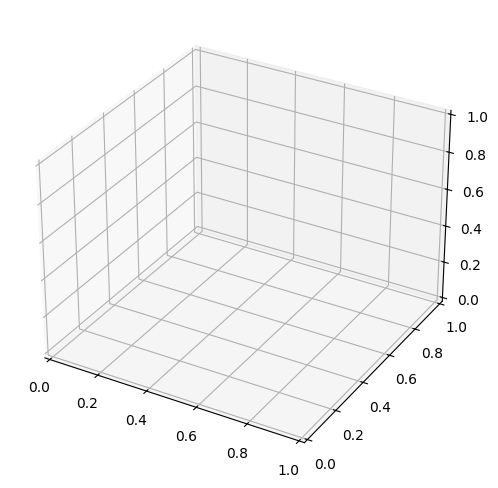

In [52]:
fig = plt.figure(figsize=(6, 6), dpi=100)
ax = fig.add_subplot(111, projection='3d')

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_3d = cv2.VideoWriter(output_3d_path, fourcc, fps, (600, 600))

In [55]:
frame_idx = 0
with vision.HandLandmarker.create_from_options(options) as detector:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        timestamp_ms = int((frame_idx / fps) * 1000)
        result = detector.detect_for_video(mp_image, timestamp_ms)

        ax.clear()

        ax.set_xlim3d([-0.4, 0.4])
        ax.set_ylim3d([-0.4, 0.4])
        ax.set_zlim3d([-0.4, 0.4])
        ax.set_xlabel('X (m)')
        ax.set_ylabel('Y (m)')
        ax.set_zlabel('Z (m)')
        ax.set_title(f'Frame: {frame_idx}')

        ax.view_init(elev=20, azim=45)

        #3D関節と位置移動の計算
        if result.hand_world_landmarks and result.hand_landmarks:
            for hand_world_lms, hand_2d_lms in zip(result.hand_world_landmarks, result.hand_landmarks):
                wrist_2d = hand_2d_lms[0]
                offset_x = (wrist_2d.x - 0.5) * 1.2  #X方向の移動量
                offset_y = -(wrist_2d.y - 0.5) * 1.2 #Y方向の移動量
                offset_z = wrist_2d.z * 0.5          #奥行きの移動量推定

                xs = [lm.x + offset_x for lm in hand_world_lms]
                ys = [lm.y + offset_y for lm in hand_world_lms]
                zs = [lm.z + offset_z for lm in hand_world_lms]

                # 関節点 (緑)
                ax.scatter(xs, ys, zs, c='green', s=20)

                # 骨格線 (赤)
                for start, end in HAND_CONNECTIONS:
                    ax.plot([xs[start], xs[end]],
                            [ys[start], ys[end]],
                            [zs[start], zs[end]], c='red', linewidth=2)

        fig.canvas.draw()
        rgba = np.asarray(fig.canvas.buffer_rgba())
        img_bgr = cv2.cvtColor(rgba, cv2.COLOR_RGBA2BGR)
        out_3d.write(img_bgr)

        frame_idx += 1

In [54]:
cap.release()
out_3d.release()
plt.close()